In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import numpy as np
import pandas as pd
from tqdm import tqdm
from stsci.skypac import pamutils
from astropy.wcs.utils import proj_plane_pixel_scales
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator

from astroquery.mast import Observations
import os
import glob
import shutil


import matplotlib.pylab as pylab
plt.style.use("science")
params = {
         'axes.labelsize': 15,
         'axes.titlesize': 25,
         'ytick.labelsize' :12,
         'xtick.labelsize' :12,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }
pylab.rcParams.update(params)

def draw_scale_and_compass(ax, cutout, wcs, rotation=0, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.001, color="k", lw=2, textpad=5, fontsize=15):
    hdr = wcs.to_header()
    pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs) # in degrees /pixels
    pixel_scale = np.mean([pixel_scale_x, pixel_scale_y]) # for drawing arrows
    M, N = cutout.shape
    
    # nice doc here http://montage.ipac.caltech.edu/docs/headers.html
    # Remember that PC maps pixels to world, so it include a mirror flip of the j coordinate (East-West)
    pc_matrix = wcs.pixel_scale_matrix
    north = np.array([1, 0])
    east = np.array([0, -1]) # accounts for the mirror flip of that coordinate to stay in pixel space
    # Using these prints, the angle of rotation should be printed has the same (+180 undo the mirror flip)
    # print(np.arctan2(pc_matrix[1, 0], pc_matrix[0, 0]) * 180 / np.pi - 90)
    # print(np.arctan2(-pc_matrix[0, 1], pc_matrix[1, 1]) * 180 / np.pi - 90 + 180)
    # Now rotate PC matrix onto our projected coordinate system. This will be useful when images are rotated by 90 degrees or 180 etc. 
    assert rotation % 90 == 0, "Rotation should only be used for images flipped by 90 or 180 degrees"
    theta = rotation * np.pi / 180 / 2 # divide by two to apply this to the PC matrix
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    pc_matrix = R @ pc_matrix @ R.T
    
    # North arrow 
    ndx = (pc_matrix @ north)[0] * compass_size * N / pixel_scale # apply minus sign to recover the orientation of the image
    ndy = (pc_matrix @ north)[1] * compass_size * N / pixel_scale
    # East arrow
    edx = (pc_matrix @ east)[0] * compass_size * N / pixel_scale
    edy = (pc_matrix @ east)[1] * compass_size * N / pixel_scale
    # some convenient padding solutions
    nrx = abs(ndx) / np.sqrt(ndx**2 + ndy**2) 
    nry = abs(ndy) / np.sqrt(ndx**2 + ndy**2)
    erx = edx / np.sqrt(edx**2 + edy**2)
    ery = -edy / np.sqrt(edx**2 + edy**2)
    # Orientation of the letters N and E
    angle = (np.arctan2(np.abs(ndy), ndx) - np.pi / 2) * 180 / np.pi
    
    # Scale bar
    ax.plot([x0*N, x0*N + scale/pixel_scale_y/3600], [y0*M, y0*M], linewidth=lw, color=color)
    ax.text(x0*N + scale/pixel_scale_x/2/3600, y0*M+textpad/2, f"{abs(scale)}''", fontsize=fontsize, color=color, ha='center', weight='bold')

    # North arrow, on the bottom right corner, pointing up
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=ndx, dy=ndy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+ndx+textpad*nrx, y0*M+ndy+textpad*nry, "N", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    
    # East arrow, on the bottom right corner, pointing left
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=edx, dy=edy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+edx+4*textpad*erx/3, y0*M+edy+4*textpad*ery/3, "E", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    return ax



The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [18]:
# For now, only collect flt files from HST. JWST has different calibration steps which need to be understood
# Only pixk observation with longest integration
obs_table = Observations.query_criteria(target_name=["SMACS*J0723.3-7327"], 
                                        project=["HST"],
                                        filters=["F105W", "F125W", "F160W"],
                                        t_exptime=[1500, 10000]
                                        # project=["HST", "JWST"], 
                                        # filters=["F105W",  "F115W", "F125W", "F150W", "F160W"],
                                       )
# obs_table = obs_table.to_pandas()
obs_table = obs_table[["GR" not in f for f in obs_table["filters"]]]
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str4,str6,str7,str3,str5,str8,str17,str32,str54,float64,float64,str5,str8,int64,float64,float64,float64,float64,float64,str43,float64,str5,str2,int64,str421,str34,str113,str6,bool,float64,str9,str9
science,HST,CALWF3,WFC3/IR,HST,F125W,Infrared,SMACSJ0723.3-7327,CLUSTER OF GALAXIES;GRAVITATIONA,iczgza010,110.8310852801,-73.45445449822,image,"Coe, Dan",3,57938.8922409375,57938.97239054398,2462.0,1092.6,1405.5,RELICS: Reionization Lensing Cluster Survey,57939.46166665,14096,GO,--,POLYGON 110.81560803 -73.42898423 110.81527862422057 -73.429103201752568 110.81507449 -73.42905694 110.74100661 -73.45575258 110.74167881861921 -73.455905065821867 110.74164525 -73.45591714 110.84647297 -73.4796369 110.8468032456873 -73.4795178403877 110.84700758 -73.47956396 110.92101234 -73.45283085 110.92033946980041 -73.452679124505437 110.92037291 -73.45266702 110.81560803 -73.42898423 110.81560803 -73.42898423,mast:HST/product/iczgza010_drz.jpg,mast:HST/product/iczgza010_drz.fits,PUBLIC,False,nan,25865653,140702290
science,HST,CALWF3,WFC3/IR,HST,F160W,Infrared,SMACSJ0723.3-7327,CLUSTER OF GALAXIES;GRAVITATIONA,iczgzb010,110.8310479746,-73.45445470924,image,"Coe, Dan",3,57939.95111793982,57940.03126793981,2462.0,1393.8999999999999,1692.4,RELICS: Reionization Lensing Cluster Survey,57940.61834485,14096,GO,--,POLYGON 110.82402156 -73.42868304 110.82365437988088 -73.428792722892325 110.8234661 -73.42874114 110.74094548 -73.45333938 110.74156437911962 -73.453509161359349 110.7415269 -73.45352031 110.83805543 -73.47993705 110.83842343073646 -73.479827398534255 110.83861156 -73.47987876 110.92111973 -73.45524206 110.92049972445147 -73.455073011894143 110.92053676 -73.45506193 110.82402156 -73.42868304 110.82402156 -73.42868304,mast:HST/product/iczgzb010_drz.jpg,mast:HST/product/iczgzb010_drz.fits,PUBLIC,False,nan,25865654,140703881
science,HLSP,RELICS,WFC3/IR,HST,F160W,Infrared,SMACSJ0723.3-7327,--,hlsp_relics_hst_wfc3ir-30mas_smacs0723m73_f160w_v1_drz,110.8334902931617,-73.45420265962855,image,Dan Coe,4,57817.71964505,57858.81802463,2061.746276,1393.8999999999999,1692.4,--,59984.47771997,14096,--,--,POLYGON 110.851102 -73.478594 110.744489 -73.462709 110.81412 -73.427235 110.918241 -73.443961 110.851102 -73.478594,--,mast:HLSP/relics/smacs0723m73/images/30mas-resolution/hlsp_relics_hst_wfc3ir-30mas_smacs0723m73_f160w_v1_wht.fits,PUBLIC,False,nan,137594233,251996593
science,HLSP,RELICS,WFC3/IR,HST,F105W,Infrared,SMACSJ0723.3-7327,--,hlsp_relics_hst_wfc3ir-30mas_smacs0723m73_f105w_v1_drz,110.8334902931617,-73.45420265962855,image,Dan Coe,4,57817.7039969,57858.79919352,1511.741578,901.2,1204.1000000000001,--,59984.47771997,14096,--,--,POLYGON 110.851102 -73.478594 110.744459 -73.462709 110.81339 -73.42726 110.918241 -73.443952 110.851102 -73.478594,--,mast:HLSP/relics/smacs0723m73/images/30mas-resolution/hlsp_relics_hst_wfc3ir-30mas_smacs0723m73_f105w_v1_wht.fits,PUBLIC,False,nan,137594295,251996689
science,HLSP,RELICS,WFC3/IR,HST,F105W,Infrared,SMACSJ0723.3-7327,--,hlsp_relics_hst_wfc3ir-60mas_smacs0723m73_f105w_v1_drz,110.8334902931617,-73.45420265962855,image,Dan Coe,4,57817.7039969,57858.79919352,1511.741578,901.2,1204.1000000000001,--,59984.47771997,14096,--,--,POLYGON 110.851131 -73.478585 110.744489 -73.462717 110.814149 -73.427218 110.918241 -73.443952 110.851131 -73.478585,--,mast:HLSP/relics/smacs0723m73/images/60mas-resolution/hlsp_relics_hst_wfc3ir-60mas_smacs0723m73_f105w_v1_wht.fits,PUBLIC,False,nan,137594375,251996801
science,HLSP,RELICS,WFC3/IR,HST,F160W,Infrared,SMACSJ0723.3-7327,--,hlsp_relics_hst_wfc3ir-60mas_smacs0723m73_f160w_v1_drz,110.8334902931617,-73.45420265962855,image,Dan Coe,4,5781

In [19]:

# project = "HST"
# filters = ["F105W", "F125W", "F160W"]
# targets = []
# for f in filters:
#     toi = obs_table[obs_table["project"] == project].to_pandas()
#     toi = toi.reset_index()
#     targets.append(toi[toi["filters"] == f].iloc[toi[toi["filters"] == f]["t_exptime"].argmax()])
# toi = pd.DataFrame(targets, columns=obs_table.keys())
# toi

In [21]:
products = Observations.get_product_list(obs_table)
Observations.filter_products(products, mrp_only=False, productSubGroupDescription=['FLC', 'FLT'])

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level
str9,str4,str5,str54,str62,str1,str113,str9,str28,str11,str1,str7,str19,str5,str59,int64,str9,str6,int64
26648590,HST,image,hst_14096_za_wfc3_ir_f125w_iczgzaj1,HAP flat-field product,D,mast:HST/product/hst_14096_za_wfc3_ir_f125w_iczgzaj1_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_za_wfc3_ir_f125w_iczgzaj1_flt.fits,16634880,25865653,PUBLIC,2
26648703,HST,image,hst_14096_za_wfc3_ir_f125w_iczgzaj2,HAP flat-field product,D,mast:HST/product/hst_14096_za_wfc3_ir_f125w_iczgzaj2_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_za_wfc3_ir_f125w_iczgzaj2_flt.fits,16634880,25865653,PUBLIC,2
26648586,HST,image,hst_14096_za_wfc3_ir_f125w_iczgzaj4,HAP flat-field product,D,mast:HST/product/hst_14096_za_wfc3_ir_f125w_iczgzaj4_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_za_wfc3_ir_f125w_iczgzaj4_flt.fits,16634880,25865653,PUBLIC,2
26648707,HST,image,hst_14096_za_wfc3_ir_f125w_iczgzaj6,HAP flat-field product,D,mast:HST/product/hst_14096_za_wfc3_ir_f125w_iczgzaj6_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_za_wfc3_ir_f125w_iczgzaj6_flt.fits,16634880,25865653,PUBLIC,2
26648818,HST,image,hst_14096_zb_wfc3_ir_f160w_iczgzbma,HAP flat-field product,D,mast:HST/product/hst_14096_zb_wfc3_ir_f160w_iczgzbma_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_zb_wfc3_ir_f160w_iczgzbma_flt.fits,16634880,25865654,PUBLIC,2
26648816,HST,image,hst_14096_zb_wfc3_ir_f160w_iczgzbmb,HAP flat-field product,D,mast:HST/product/hst_14096_zb_wfc3_ir_f160w_iczgzbmb_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_zb_wfc3_ir_f160w_iczgzbmb_flt.fits,16634880,25865654,PUBLIC,2
26648817,HST,image,hst_14096_zb_wfc3_ir_f160w_iczgzbmg,HAP flat-field product,D,mast:HST/product/hst_14096_zb_wfc3_ir_f160w_iczgzbmg_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_zb_wfc3_ir_f160w_iczgzbmg_flt.fits,16634880,25865654,PUBLIC,2
26648815,HST,image,hst_14096_zb_wfc3_ir_f160w_iczgzbmm,HAP flat-field product,D,mast:HST/product/hst_14096_zb_wfc3_ir_f160w_iczgzbmm_flt.fits,SCIENCE,--,FLT,--,HAP-SVM,DrizzlePac 3.5.1,14096,hst_14096_zb_wfc3_ir_f160w_iczgzbmm_flt.fits,16634880,25865654,PUBLIC,2
25865267,HST,image,iczgzaj1q,DADS FLT file - Calibrated exposure ACS/WFC3/STIS/COS,S,mast:HST/product/iczgzaj1q_flt.fits,SCIENCE,--,FLT,--,CALWF3,3.6.2 (May-27-2021),14096,iczgzaj1q_flt.fits,16623360,25865653,PUBLIC,2


In [ ]:
# Directly download them (below is my old way of doing the same thing)
dl_tbl = Observations.download_products(filtered_products, mrp_only=False)
dl_tbl

In [22]:
# data_products = Observations.get_product_list(obs_table)
# extensions = ["flt.fits"]

# selection = []
# for i, filename in enumerate(data_products["dataURI"]):
#     for ext in extensions:
#         if ext in filename:
#             selection.append(i)
            
# data_products_of_interest = data_products[selection]
# data_products_of_interest["dataURI"]

In [23]:
# data_dir = "../data/SMACSJ0723/HST/"
# if not os.path.isdir(data_dir):
#     os.mkdir(data_dir)
# # This last line produce a shell script with curl commands ready to download our query
# Observations.download_products(data_products_of_interest, download_dir=data_dir, curl_flag=True) 

In [6]:
obs_table = Observations.query_criteria(target_name=["SMACS*J0723.3-7327"], 
                                        # project=["HST"],
                                        # filters=["F105W", "F125W", "F160W"],
                                        # t_exptime=[1500, 10000]
                                        project=["JWST"], 
                                        filters=["F105W",  "F115W", "F125W", "F150W", "F160W"],
                                       )
obs_table = obs_table[["GR" not in f for f in obs_table["filters"]]]
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str4,str7,str12,str4,str12,str8,str18,str1,str39,float64,float64,str8,str21,int64,float64,float64,float64,float64,float64,str33,float64,str4,str3,int64,str137,str65,str66,str6,bool,float64,str9,str9
science,JWST,CALJWST,NIRCAM/IMAGE,JWST,F150W,INFRARED,SMACS-J0723.3-7327,--,jw02736-o001_t001_nircam_clear-f150w,110.8274095833333,-73.45473611111112,image,"Pontoppidan, Klaus M.",3,59737.1225270853,59737.21809307871,7537.212,1331.0,1668.0,JWST Early Release Observation 10,59773.625,2736,COM,--,POLYGON 110.84199095 -73.424901326 110.92635292 -73.458423957 110.67137927 -73.510252551 110.587263939 -73.476627706,mast:JWST/product/jw02736-o001_t001_nircam_clear-f150w_i2d.jpg,mast:JWST/product/jw02736-o001_t001_nircam_clear-f150w_i2d.fits,PUBLIC,False,nan,87602570,269024821
science,JWST,CALJWST,NIRISS/IMAGE,JWST,CLEAR;F115W,INFRARED,SMACS-J0723.3-7327,--,jw02736-o003_t001_niriss_clear-f115w,110.8274095833333,-73.45473611111112,image,"Pontoppidan, Klaus M.",3,59747.32058126771,59747.41779403935,858.9439999999997,500.0,5000.0,JWST Early Release Observation 10,59773.625,2736,COM,--,POLYGON 110.859618262 -73.429664163 110.914575227 -73.464040465 110.794583409 -73.479566157 110.739818707 -73.445158516,mast:JWST/product/jw02736-o003_t001_niriss_clear-f115w_i2d.jpg,mast:JWST/product/jw02736-o003_t001_niriss_clear-f115w_i2d.fits,PUBLIC,False,nan,87602150,292571780


In [7]:
# For JWST, the level 2 (level for single exposure before stacking) has the extension "cal".
# The level 3 data (stacked) is i2d
data_products = Observations.get_product_list(obs_table)
data_products = data_products[(data_products["calib_level"] >= 2) & (data_products["productType"] == "SCIENCE")]
# Unclear which extension to use to get cal files. nis_cal is spectroscopy, do not use that one
extensions = ["nrca1_cal.fits"]#, "f150w_i2d.fits", "f115w_i2d.fits"]

selection = []
for i, filename in enumerate(data_products["dataURI"]):
    for ext in extensions:
        if ext in filename:
            selection.append(i)
            
data_products_of_interest = data_products[selection]
data_products_of_interest["dataURI"]

mast:JWST/product/jw02736001001_02103_00001_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00002_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00003_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00004_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00005_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00006_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00007_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00008_nrca1_cal.fits
mast:JWST/product/jw02736001001_02103_00009_nrca1_cal.fits


In [8]:
data_products_of_interest["dataURI"]["gs" not in data_products_of_interest["dataURI"]]

mast:JWST/product/jw02736001001_02103_00001_nrca1_cal.fits .. mast:JWST/product/jw02736001001_02103_00009_nrca1_cal.fits


In [9]:
data_dir = "../data/SMACSJ0723/JWST/"
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)
# This last line produce a shell script with curl commands ready to download our query
Observations.download_products(data_products_of_interest, download_dir=data_dir, curl_flag=True) 

Local Path,Status,Message
str54,str8,object
../data/SMACSJ0723/JWST/mastDownload_20230823011358.sh,COMPLETE,None


# Science cutouts

In [2]:
coord1 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(u.hourangle, u.deg))
coord3 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(u.hourangle, u.deg))
coord4 = SkyCoord("7:23:01.6118", "-73:26:45.888", unit=(u.hourangle, u.deg))

In [3]:
data_dir = "../data/SMACSJ0723/HST/"
flt_paths = glob.glob(data_dir + "*flt.fits")

# Only use first visit for F105W to avoid having to deal with aligning 2 visitis, which is harder than aligning images from a single visit
filters = ["F105WO1", "F125W", "F160W"]

flt_paths_sorted = {
    "F160W": [p for p in flt_paths if "f160w" in p],
    "F125W": [p for p in flt_paths if "f125w" in p],
    "F105W": [p for p in flt_paths if "f160w" not in p and "f125w" not in p],
    "F105WO1": [p for p in flt_paths if "f160w" not in p and "f125w" not in p and "za" in p], # first orbit (infered from the TIME-OBS and DATE-OBS keywords
    "F105WO2": [p for p in flt_paths if "f160w" not in p and "f125w" not in p and "bm" in p]  # second orbit
}

# Make HST science cutouts

In [4]:
import sys
sys.path.append("../scripts/")
from preprocessing import *

In [6]:
# Check that F015W is indeed made of 2 visits (or HST orbits)
for path in flt_paths_sorted["F105W"]:
    data = fits.open(path)
    print(data[0].header["DATE-OBS"], data[0].header["TIME-OBS"])

2017-07-04 23:10:11
2017-07-06 00:34:58
2017-07-05 22:49:36
2017-07-05 22:59:51
2017-07-04 21:24:49
2017-07-04 22:58:16
2017-07-04 21:35:04
2017-07-06 00:23:03


iczgzaj6q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.80e-01 electrons/s


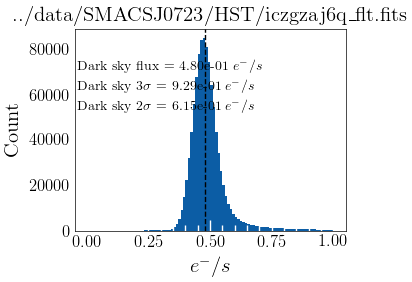

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj1q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.05e-01 electrons/s


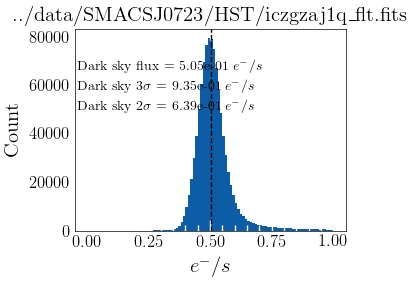

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj4q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.79e-01 electrons/s


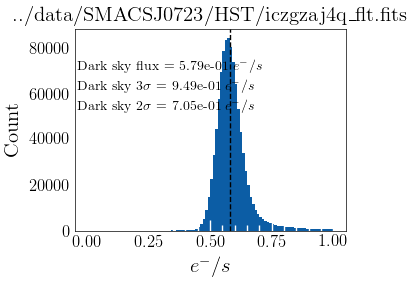

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj2q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.81e-01 electrons/s


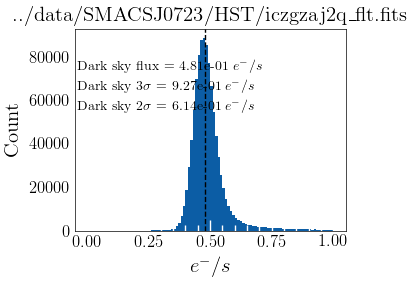

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj1_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.05e-01 electrons/s


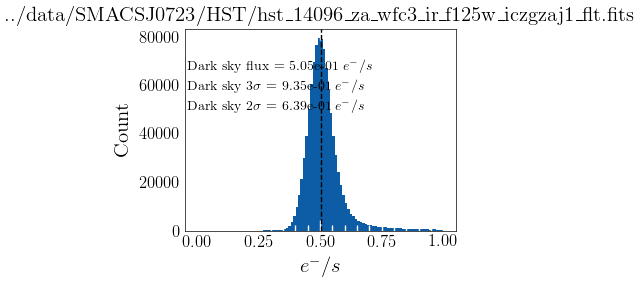

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj6_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.80e-01 electrons/s


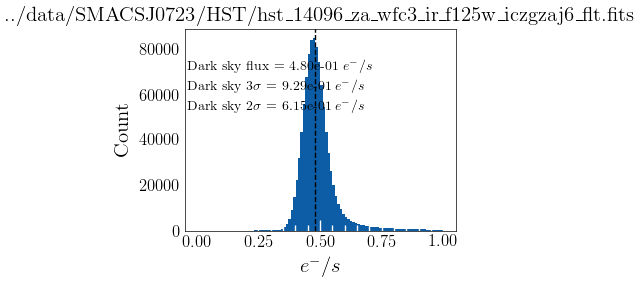

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj2_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.81e-01 electrons/s


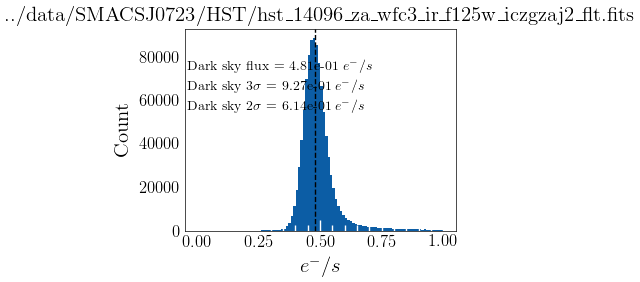

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj4_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.79e-01 electrons/s


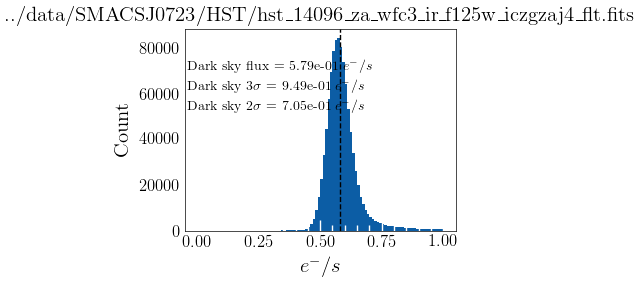

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmm_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.44e-01 electrons/s


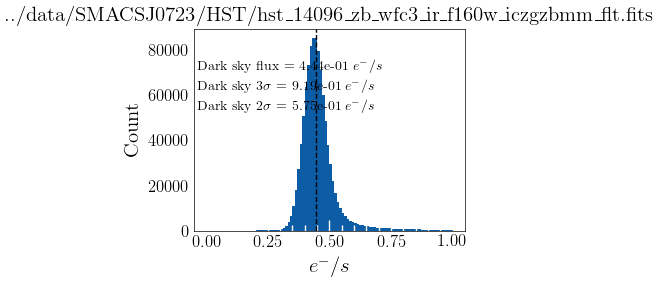

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmg_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.73e-01 electrons/s


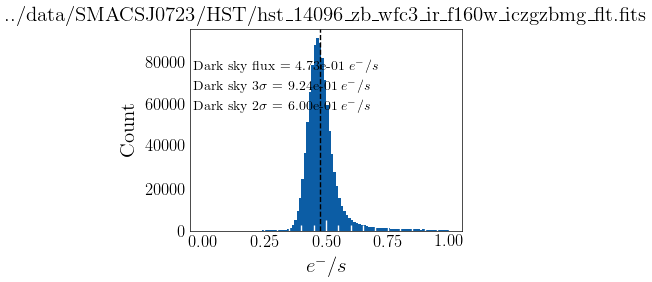

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbma_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.78e-01 electrons/s


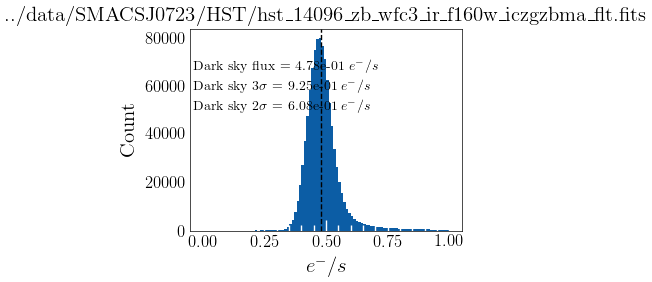

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmb_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.44e-01 electrons/s


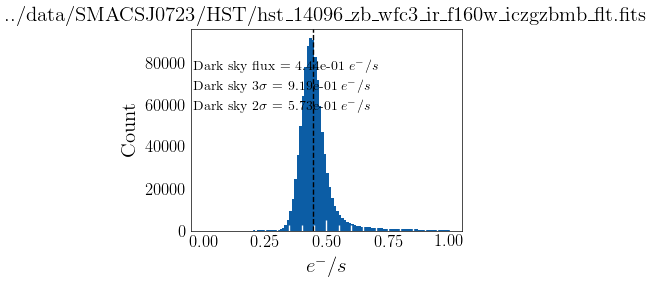

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj6q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.80e-01 electrons/s


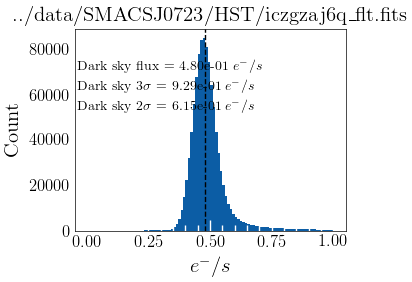

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj1q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.05e-01 electrons/s


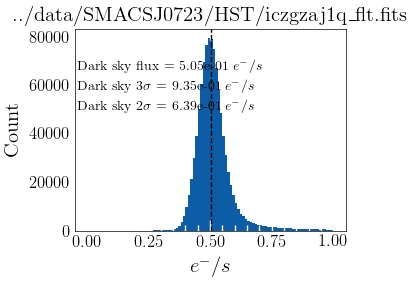

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj4q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.79e-01 electrons/s


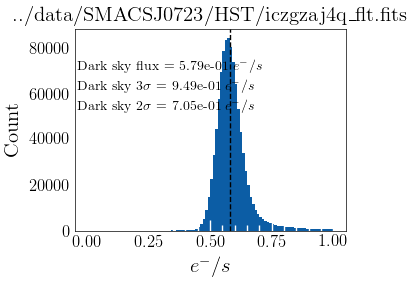

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj2q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.81e-01 electrons/s


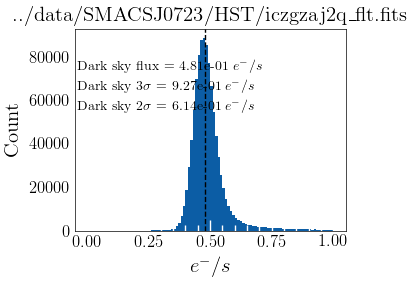

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj1_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.05e-01 electrons/s


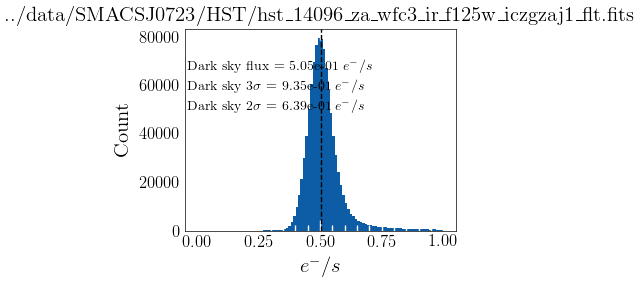

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj6_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.80e-01 electrons/s


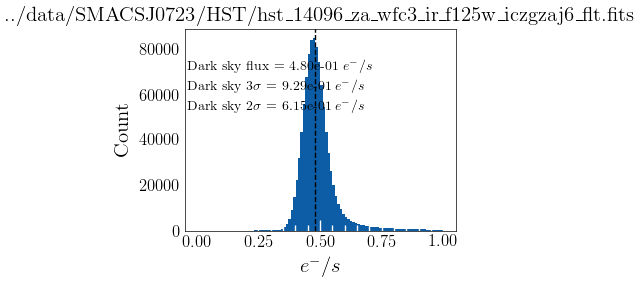

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj2_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.81e-01 electrons/s


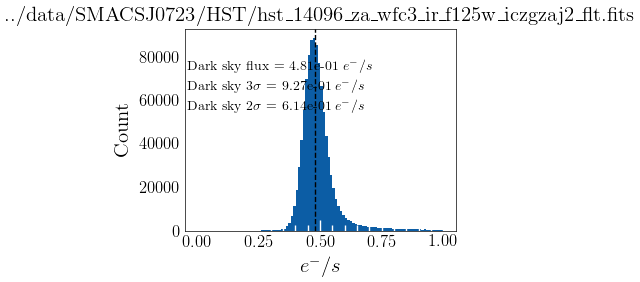

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj4_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.79e-01 electrons/s


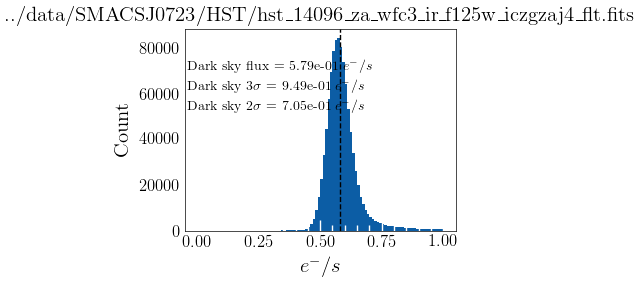

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmm_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.44e-01 electrons/s


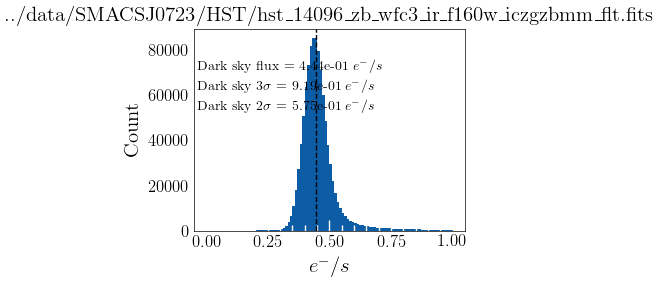

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmg_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.73e-01 electrons/s


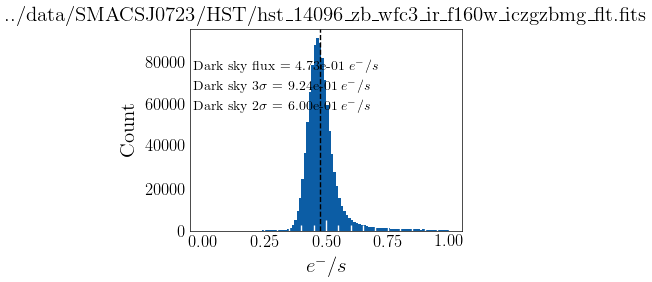

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbma_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.78e-01 electrons/s


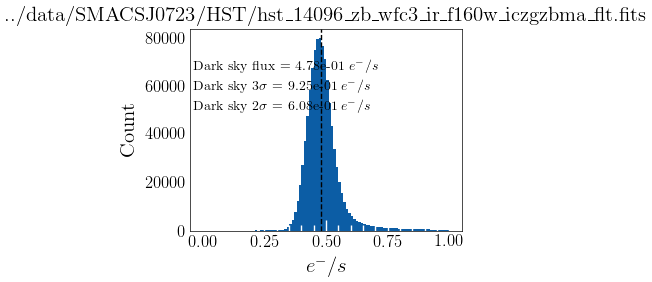

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmb_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.44e-01 electrons/s


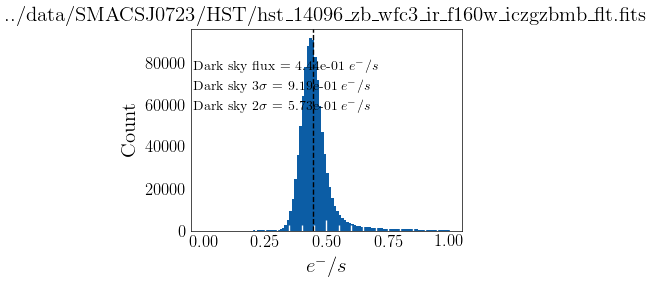

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj6q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.80e-01 electrons/s


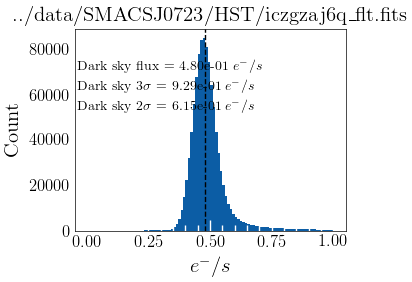

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj1q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.05e-01 electrons/s


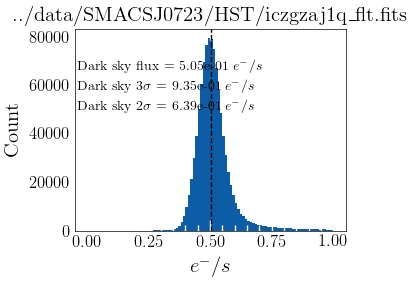

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj4q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.79e-01 electrons/s


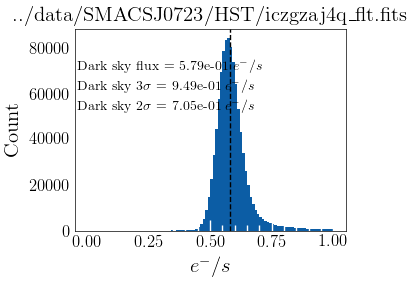

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
iczgzaj2q_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.81e-01 electrons/s


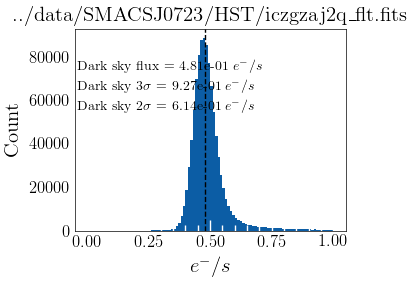

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj1_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.05e-01 electrons/s


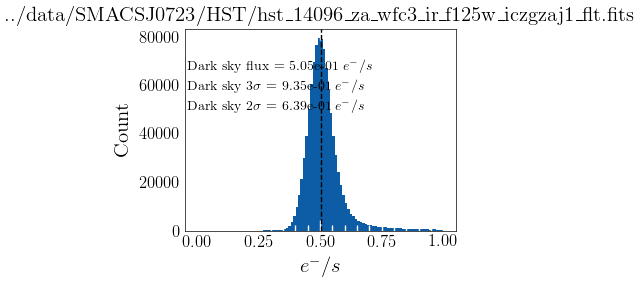

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj6_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.80e-01 electrons/s


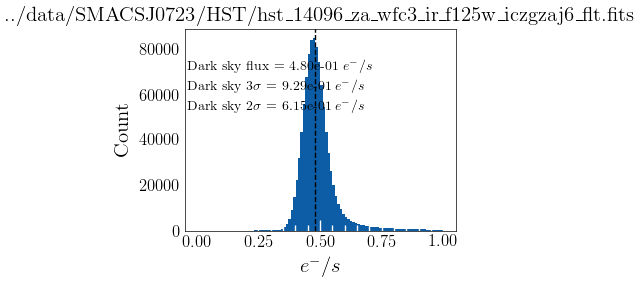

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj2_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.81e-01 electrons/s


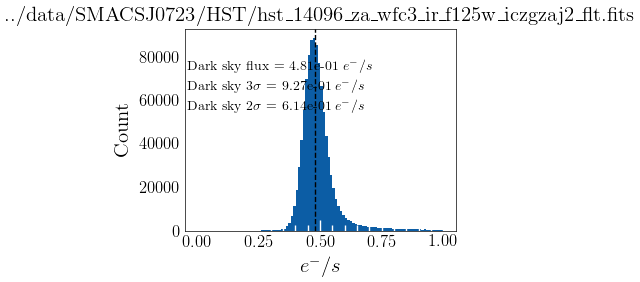

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_za_wfc3_ir_f125w_iczgzaj4_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 5.79e-01 electrons/s


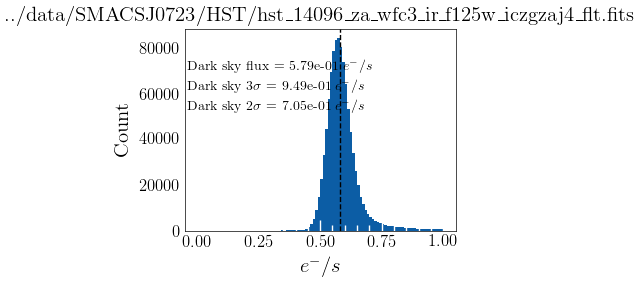

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmm_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.44e-01 electrons/s


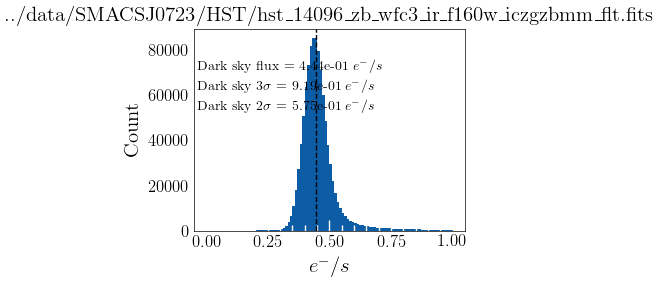

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmg_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.73e-01 electrons/s


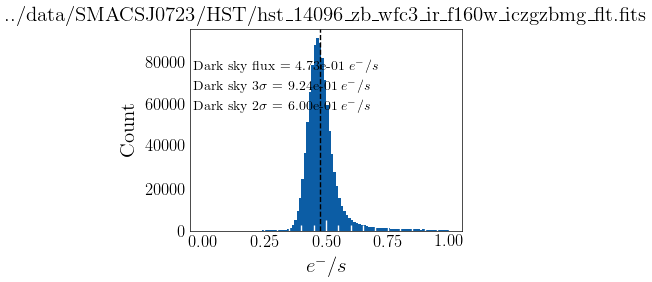

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbma_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.78e-01 electrons/s


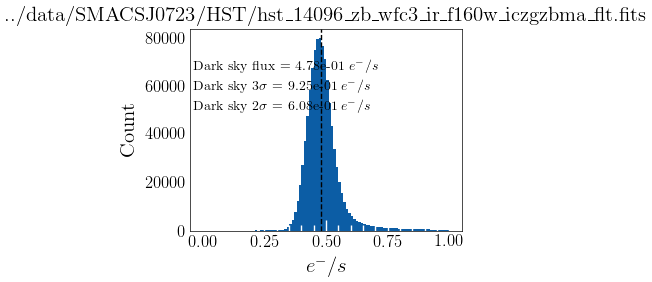

Applying PAM, dividing by EXPTIME and subtracting dark sky mode
hst_14096_zb_wfc3_ir_f160w_iczgzbmb_flt.fits
Data units not in electrons count, exposure time will not be used to normalize the data
Measured dark sky flux = 4.44e-01 electrons/s


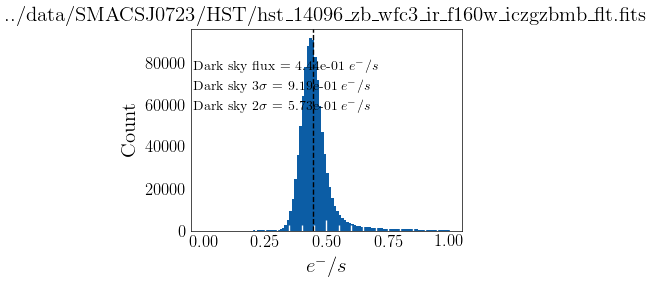

Applying PAM, dividing by EXPTIME and subtracting dark sky mode


In [7]:
targets = list(range(3))
coords = [coord1, coord2, coord3]#, coord4]
cutouts = {k: {i: [] for i in targets} for k in filters}
hdul = {k: [] for k in filters}
for target in targets:
    for f in filters:
        paths = flt_paths_sorted[f]
        for i, path in enumerate(paths):
            # Load WCS solutions and feed them to save cutout to transform the WCS of the cutout to the aligned solution
            filename = os.path.split(path)[-1]
            wcs_solution = np.load(f"../data/smacs_{filename}_target{target}_{f}_iref1_wcs_solutions.npz")
            print(filename)
            hdul_obj, data, cutout = save_cutout(f"../data/smacs_target{target}_{f}_{i}.fits",
                                            pixels=32,
                                            flc_or_flt_path=path,
                                            coordinate=coords[target],
                                            flux_smaller_than=1, # Used to compute statistics
                                            overwrite=True,
                                            verbose=1,
                                            ver=1,
                                            shift_x=wcs_solution["x"], # alignment of the cutout WCS
                                            shift_y=wcs_solution["y"],
                                            theta=wcs_solution["theta"],
                                            )
            cutouts[f][target].append(cutout)

In [9]:
wcs = cutouts["F105WO1"][0][0].wcs
# read off pixel scale in arcseconds
proj_plane_pixel_scales(wcs) * 3600

array([0.13540034, 0.1209414 ])

In [10]:
wcs = cutouts["F125W"][0][0].wcs
# read off pixel scale in arcseconds
proj_plane_pixel_scales(wcs) * 3600

array([0.13539501, 0.12093659])

In [11]:
wcs = cutouts["F160W"][0][0].wcs
# read off pixel scale in arcseconds
proj_plane_pixel_scales(wcs) * 3600

array([0.13540037, 0.12093772])

In [12]:
for f in ["F105WO1", "F125W", "F160W"]:
    print(f)
    print("photplam=", fits.open(flt_paths_sorted[f][0])[0].header["PHOTPLAM"])
    print("photflam=", fits.open(flt_paths_sorted[f][0])[0].header["PHOTfLAM"])

F105WO1
photplam= 12486.06
photflam= 2.2446e-20
F125W
photplam= 12486.06
photflam= 2.2446e-20
F160W
photplam= 15369.176
photflam= 1.9429001e-20


In [13]:
cutouts

{'F105WO1': {0: [<astropy.nddata.utils.Cutout2D at 0x7f3c038b4220>,
  1: [<astropy.nddata.utils.Cutout2D at 0x7f3be419eec0>,
  2: [<astropy.nddata.utils.Cutout2D at 0x7f3be3aee980>,
   <astropy.nddata.utils.Cutout2D at 0x7f3be3cb0df0>]},
 'F125W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f3c038bfa60>,
  1: [<astropy.nddata.utils.Cutout2D at 0x7f3be3e60dc0>,
  2: [<astropy.nddata.utils.Cutout2D at 0x7f3bdaa10a30>,
   <astropy.nddata.utils.Cutout2D at 0x7f3be3d092d0>]},
 'F160W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f3be3cea5f0>,
  1: [<astropy.nddata.utils.Cutout2D at 0x7f3c038d3e50>,
  2: [<astropy.nddata.utils.Cutout2D at 0x7f3bdaa2b460>,
   <astropy.nddata.utils.Cutout2D at 0x7f3be40f8eb0>]}}

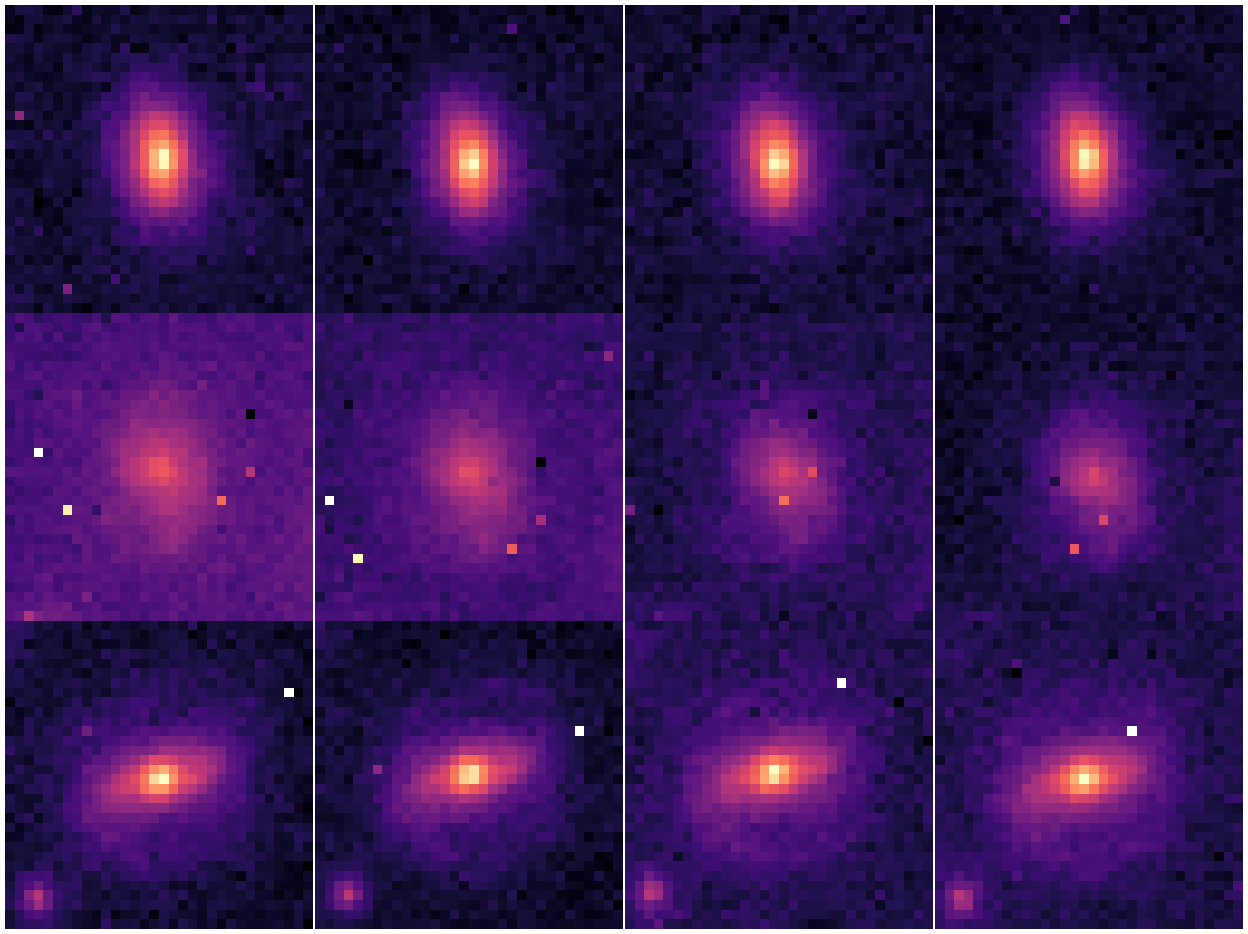

In [14]:
f = "F160W"
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

for i in range(3):
    for j in range(4):
        axs[i, j].imshow(cutouts[f][i][j].data, cmap="magma", norm=plt.cm.colors.LogNorm(vmax=7.35))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

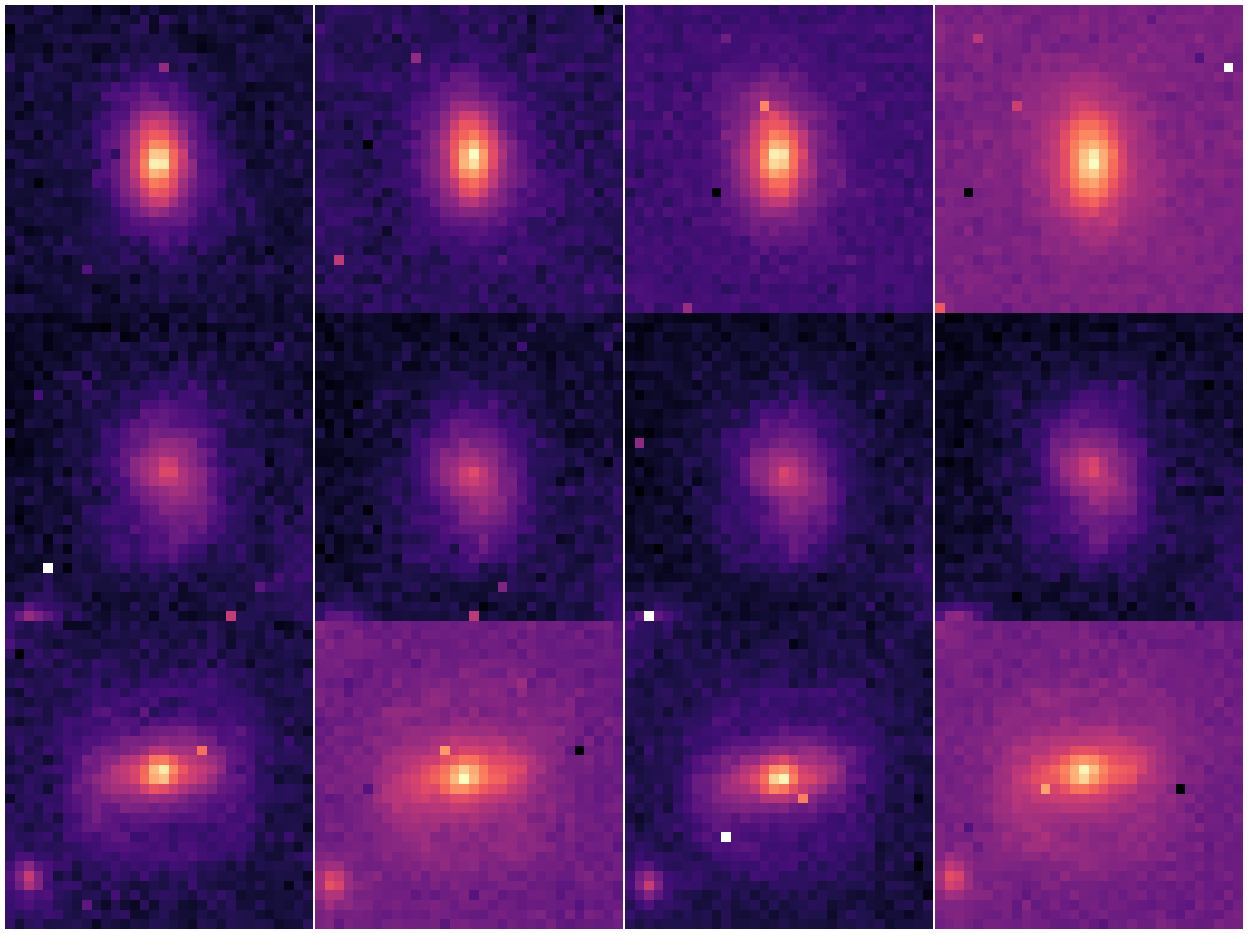

In [17]:
f = "F105WO1"
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

for i in range(3):
    for j in range(4):
        axs[i, j].imshow(cutouts[f][i][j].data, cmap="magma", norm=plt.cm.colors.LogNorm(vmax=7.35))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

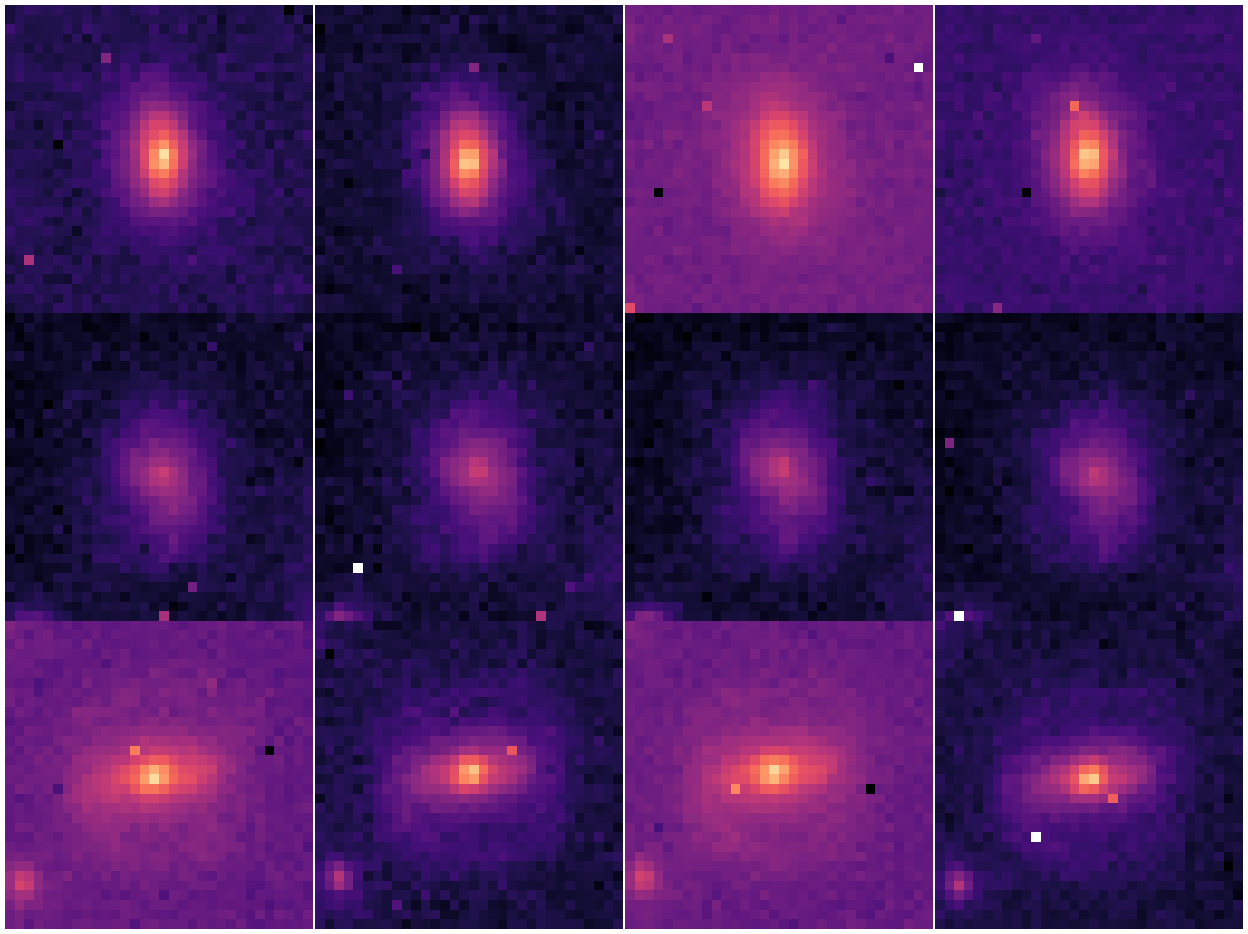

In [18]:
f = "F125W"
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

for i in range(3):
    for j in range(4):
        axs[i, j].imshow(cutouts[f][i][j].data, cmap="magma", norm=plt.cm.colors.LogNorm(vmax=10))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# Make noise dataset

In [20]:
N = 5000
size = 32
flux_criteria = 0.01
good_crops = {k: [] for k in filters}
bad_crops = {k: [] for k in filters}
for target in targets:
    for f in filters:
        paths = flt_paths_sorted[f]
        for i, path in enumerate(paths):
            good, bad = create_noise_dataset(size, N, path, flux_criteria, ver=1,  flux_smaller_than=1, return_bad_crops=True, verbose=0)
            good_crops[f].extend(good)
            bad_crops[f].extend(bad)

In [21]:
print(len(good_crops["F105W"]))

16922


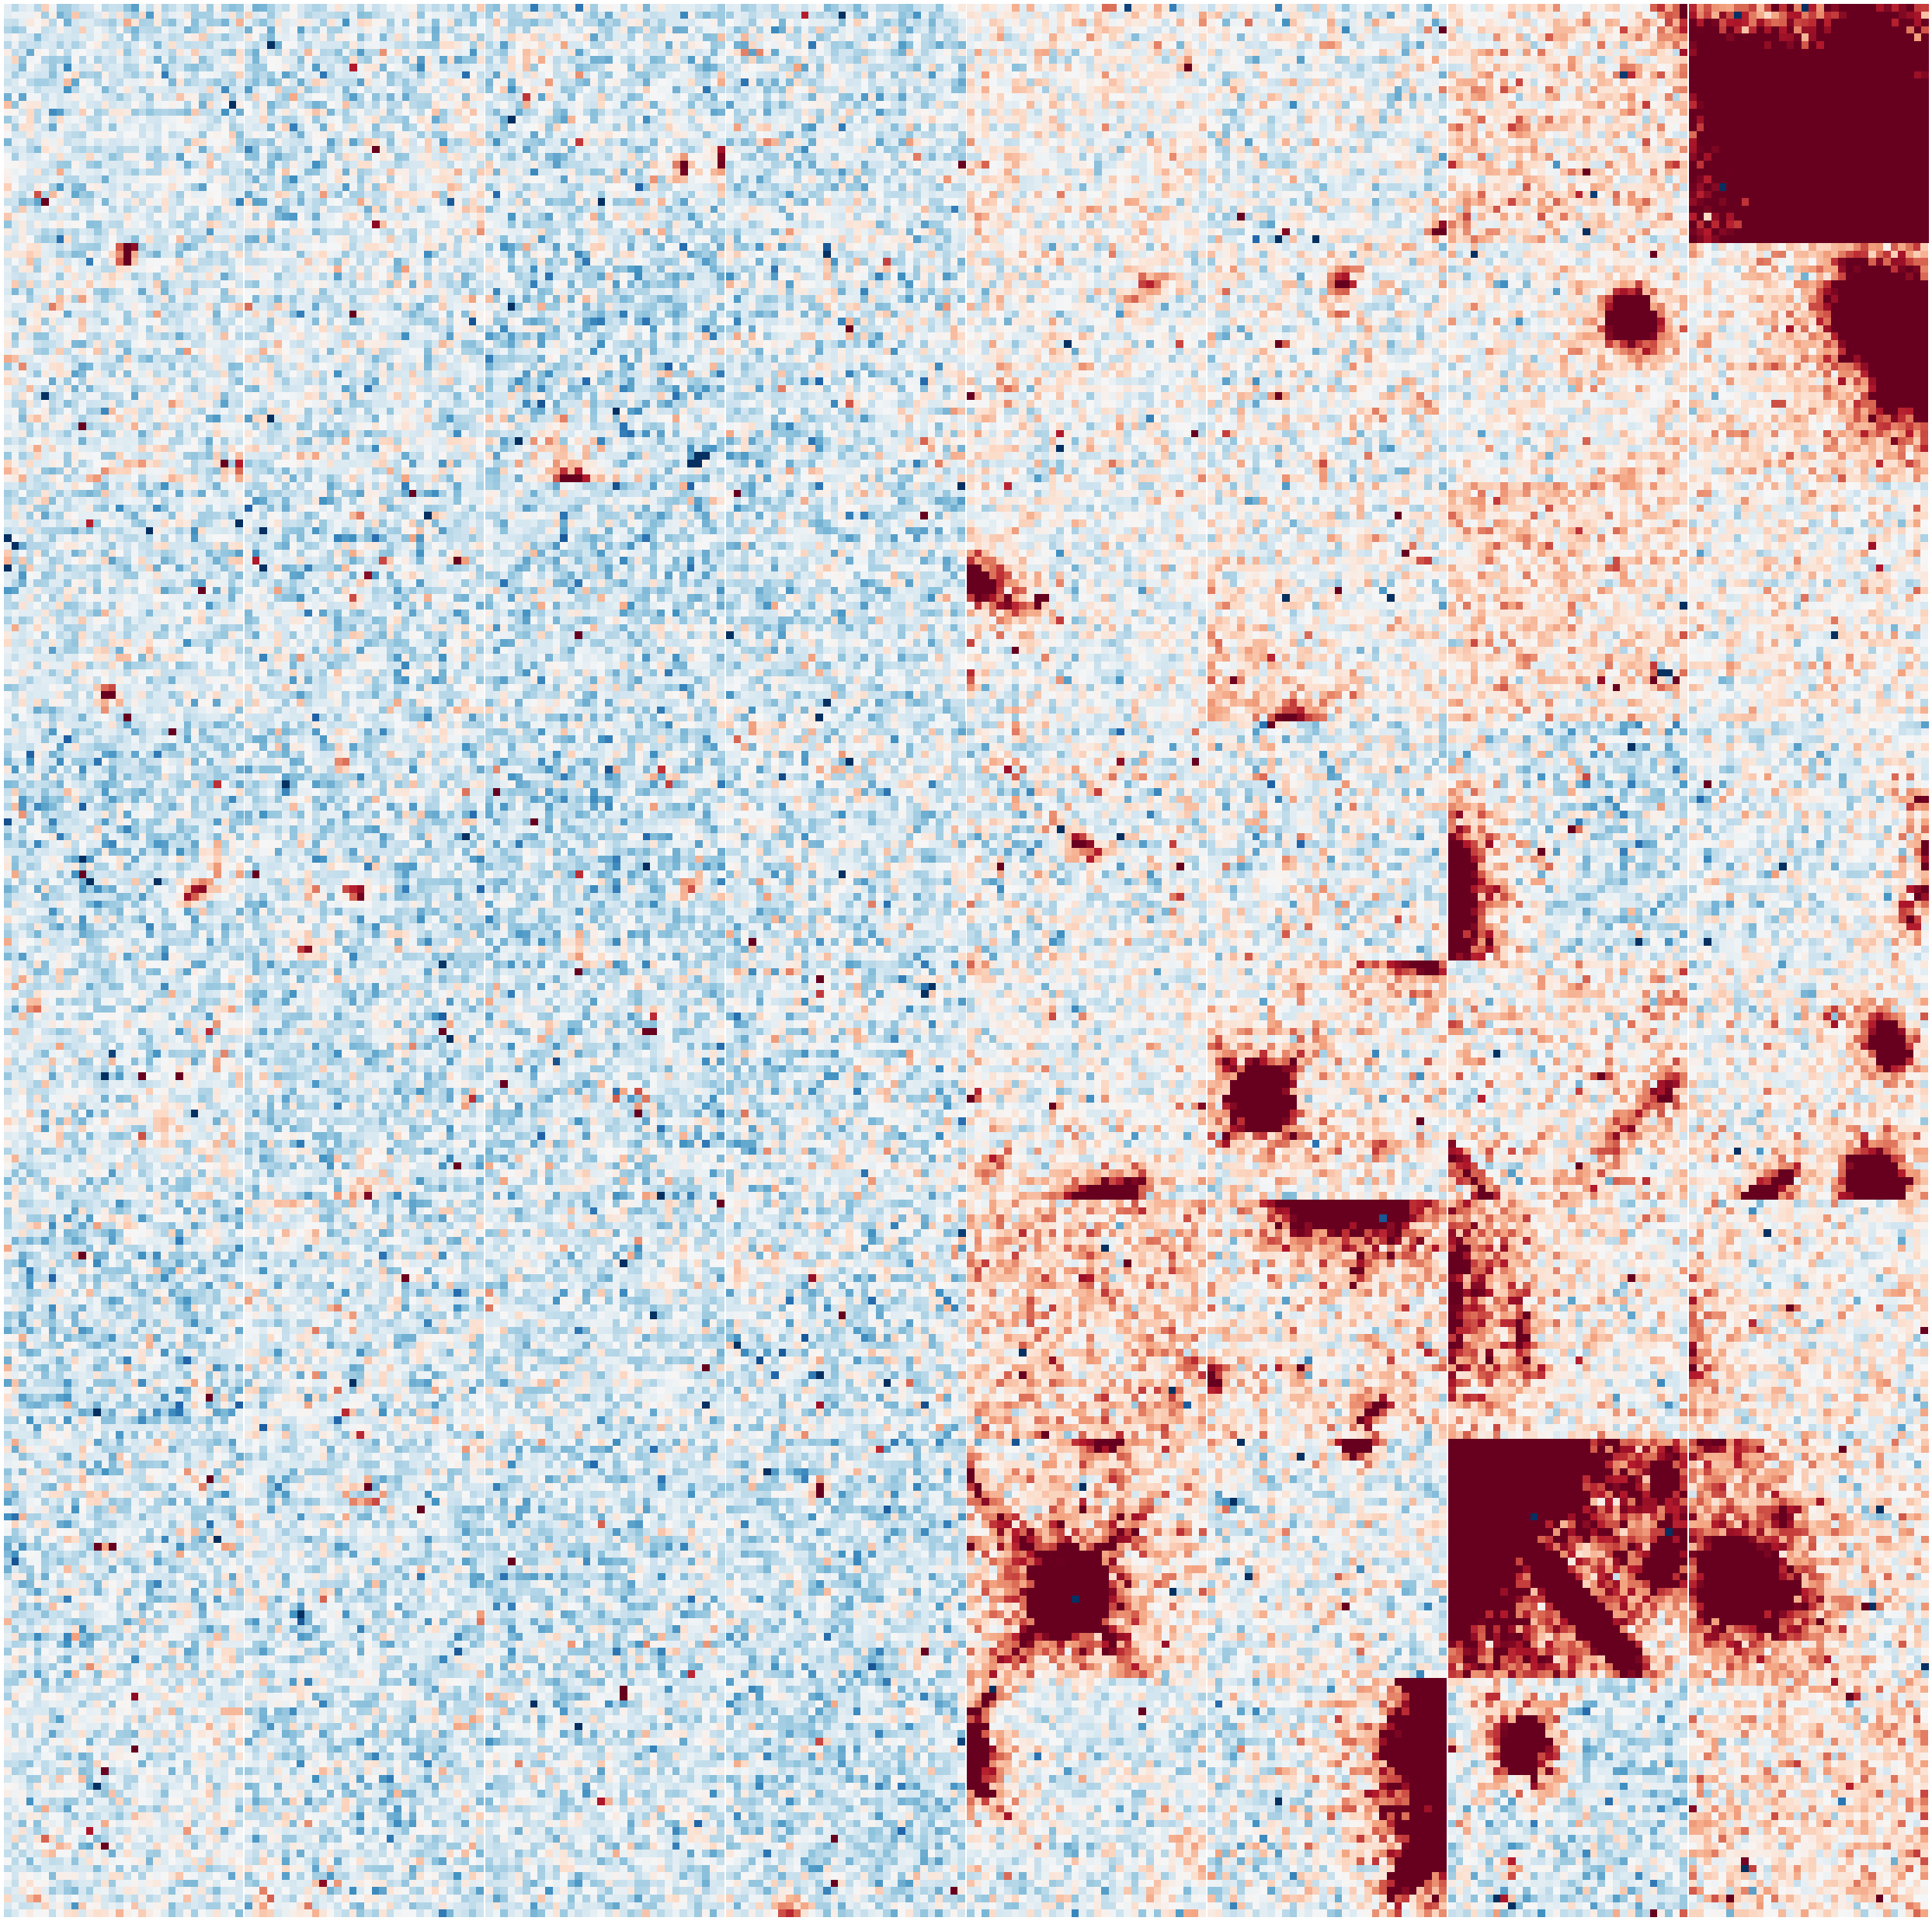

In [23]:
fig, axs = plt.subplots(8, 8, figsize=(32, 32))

F = "F105W"
for i in range(8):
    for j in range(4):
        k = np.random.randint(len(good_crops[F]))
        axs[i, j].imshow(good_crops[F][k], cmap="RdBu_r", vmin=-0.2, vmax=0.2)
        axs[i, j].axis("off")
        
    for j in range(4):
        k = np.random.randint(len(bad_crops[F]))
        axs[i, 4+j].imshow(bad_crops[F][k], cmap="RdBu_r", vmin=-0.2, vmax=0.2)
        axs[i, 4+j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

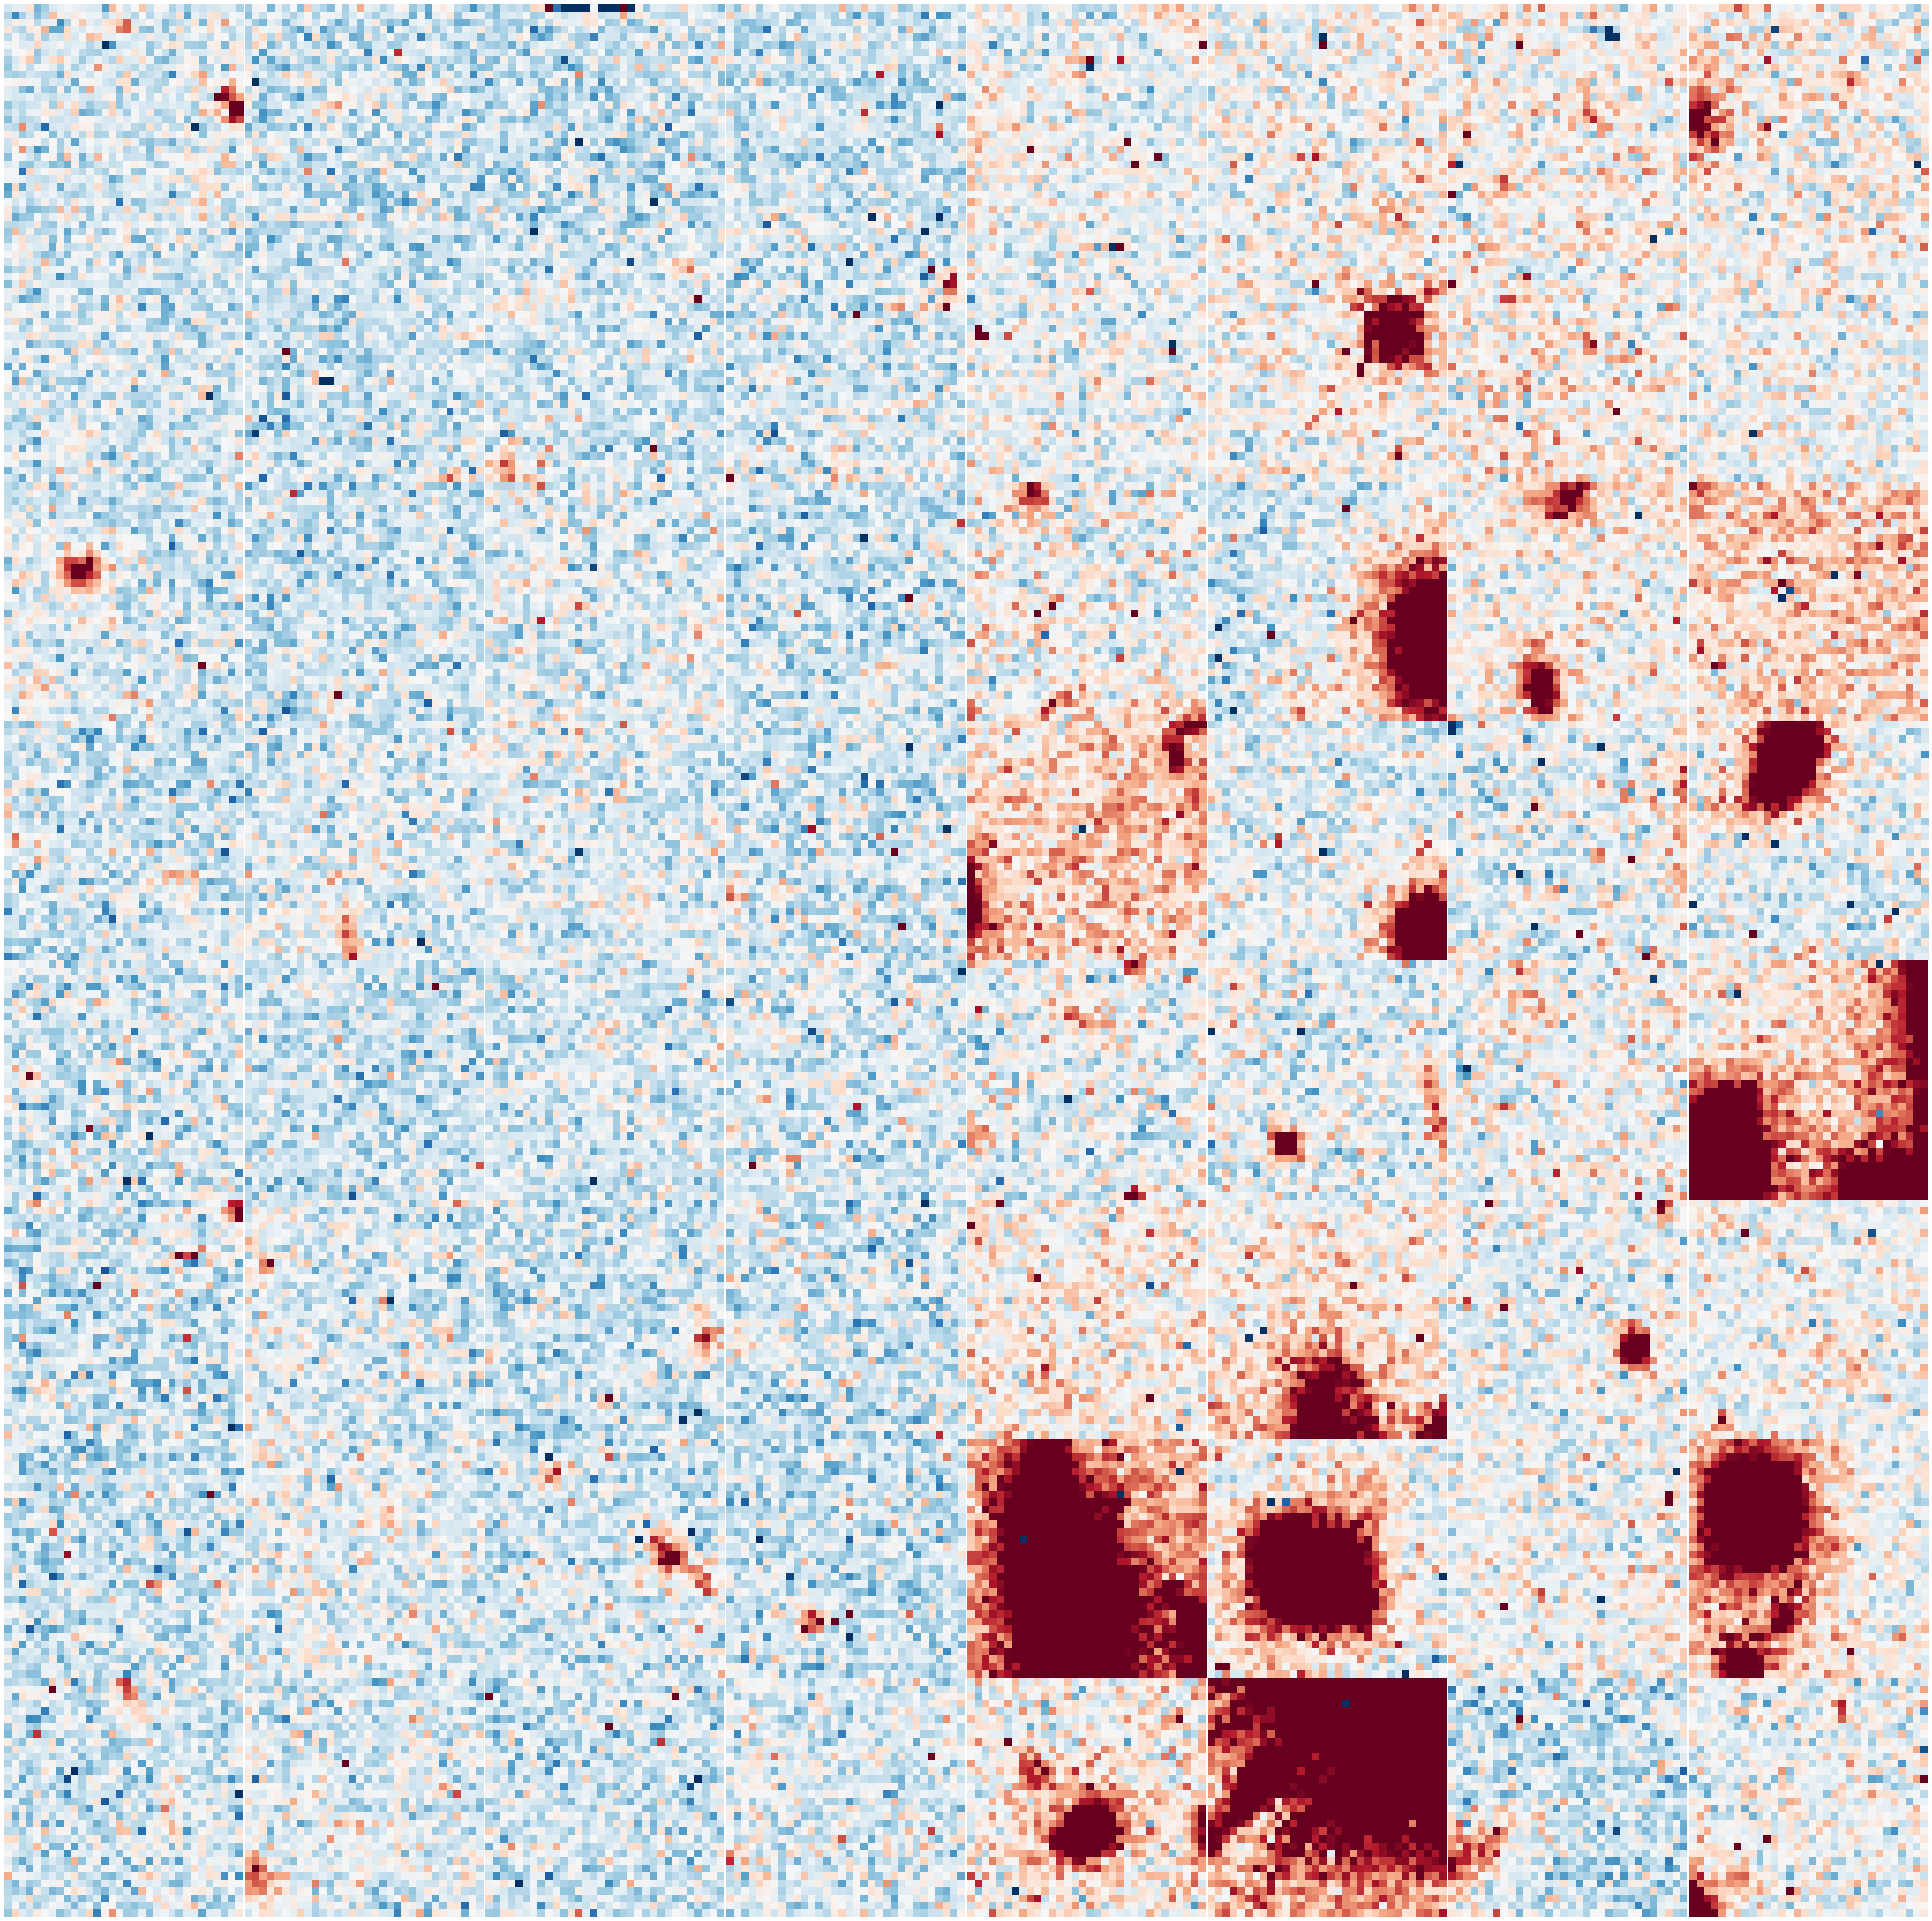

In [24]:
fig, axs = plt.subplots(8, 8, figsize=(32, 32))

F = "F125W"
for i in range(8):
    for j in range(4):
        k = np.random.randint(len(good_crops[F]))
        axs[i, j].imshow(good_crops[F][k], cmap="RdBu_r", vmin=-0.2, vmax=0.2)
        axs[i, j].axis("off")
        
    for j in range(4):
        k = np.random.randint(len(bad_crops[F]))
        axs[i, 4+j].imshow(bad_crops[F][k], cmap="RdBu_r", vmin=-0.2, vmax=0.2)
        axs[i, 4+j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

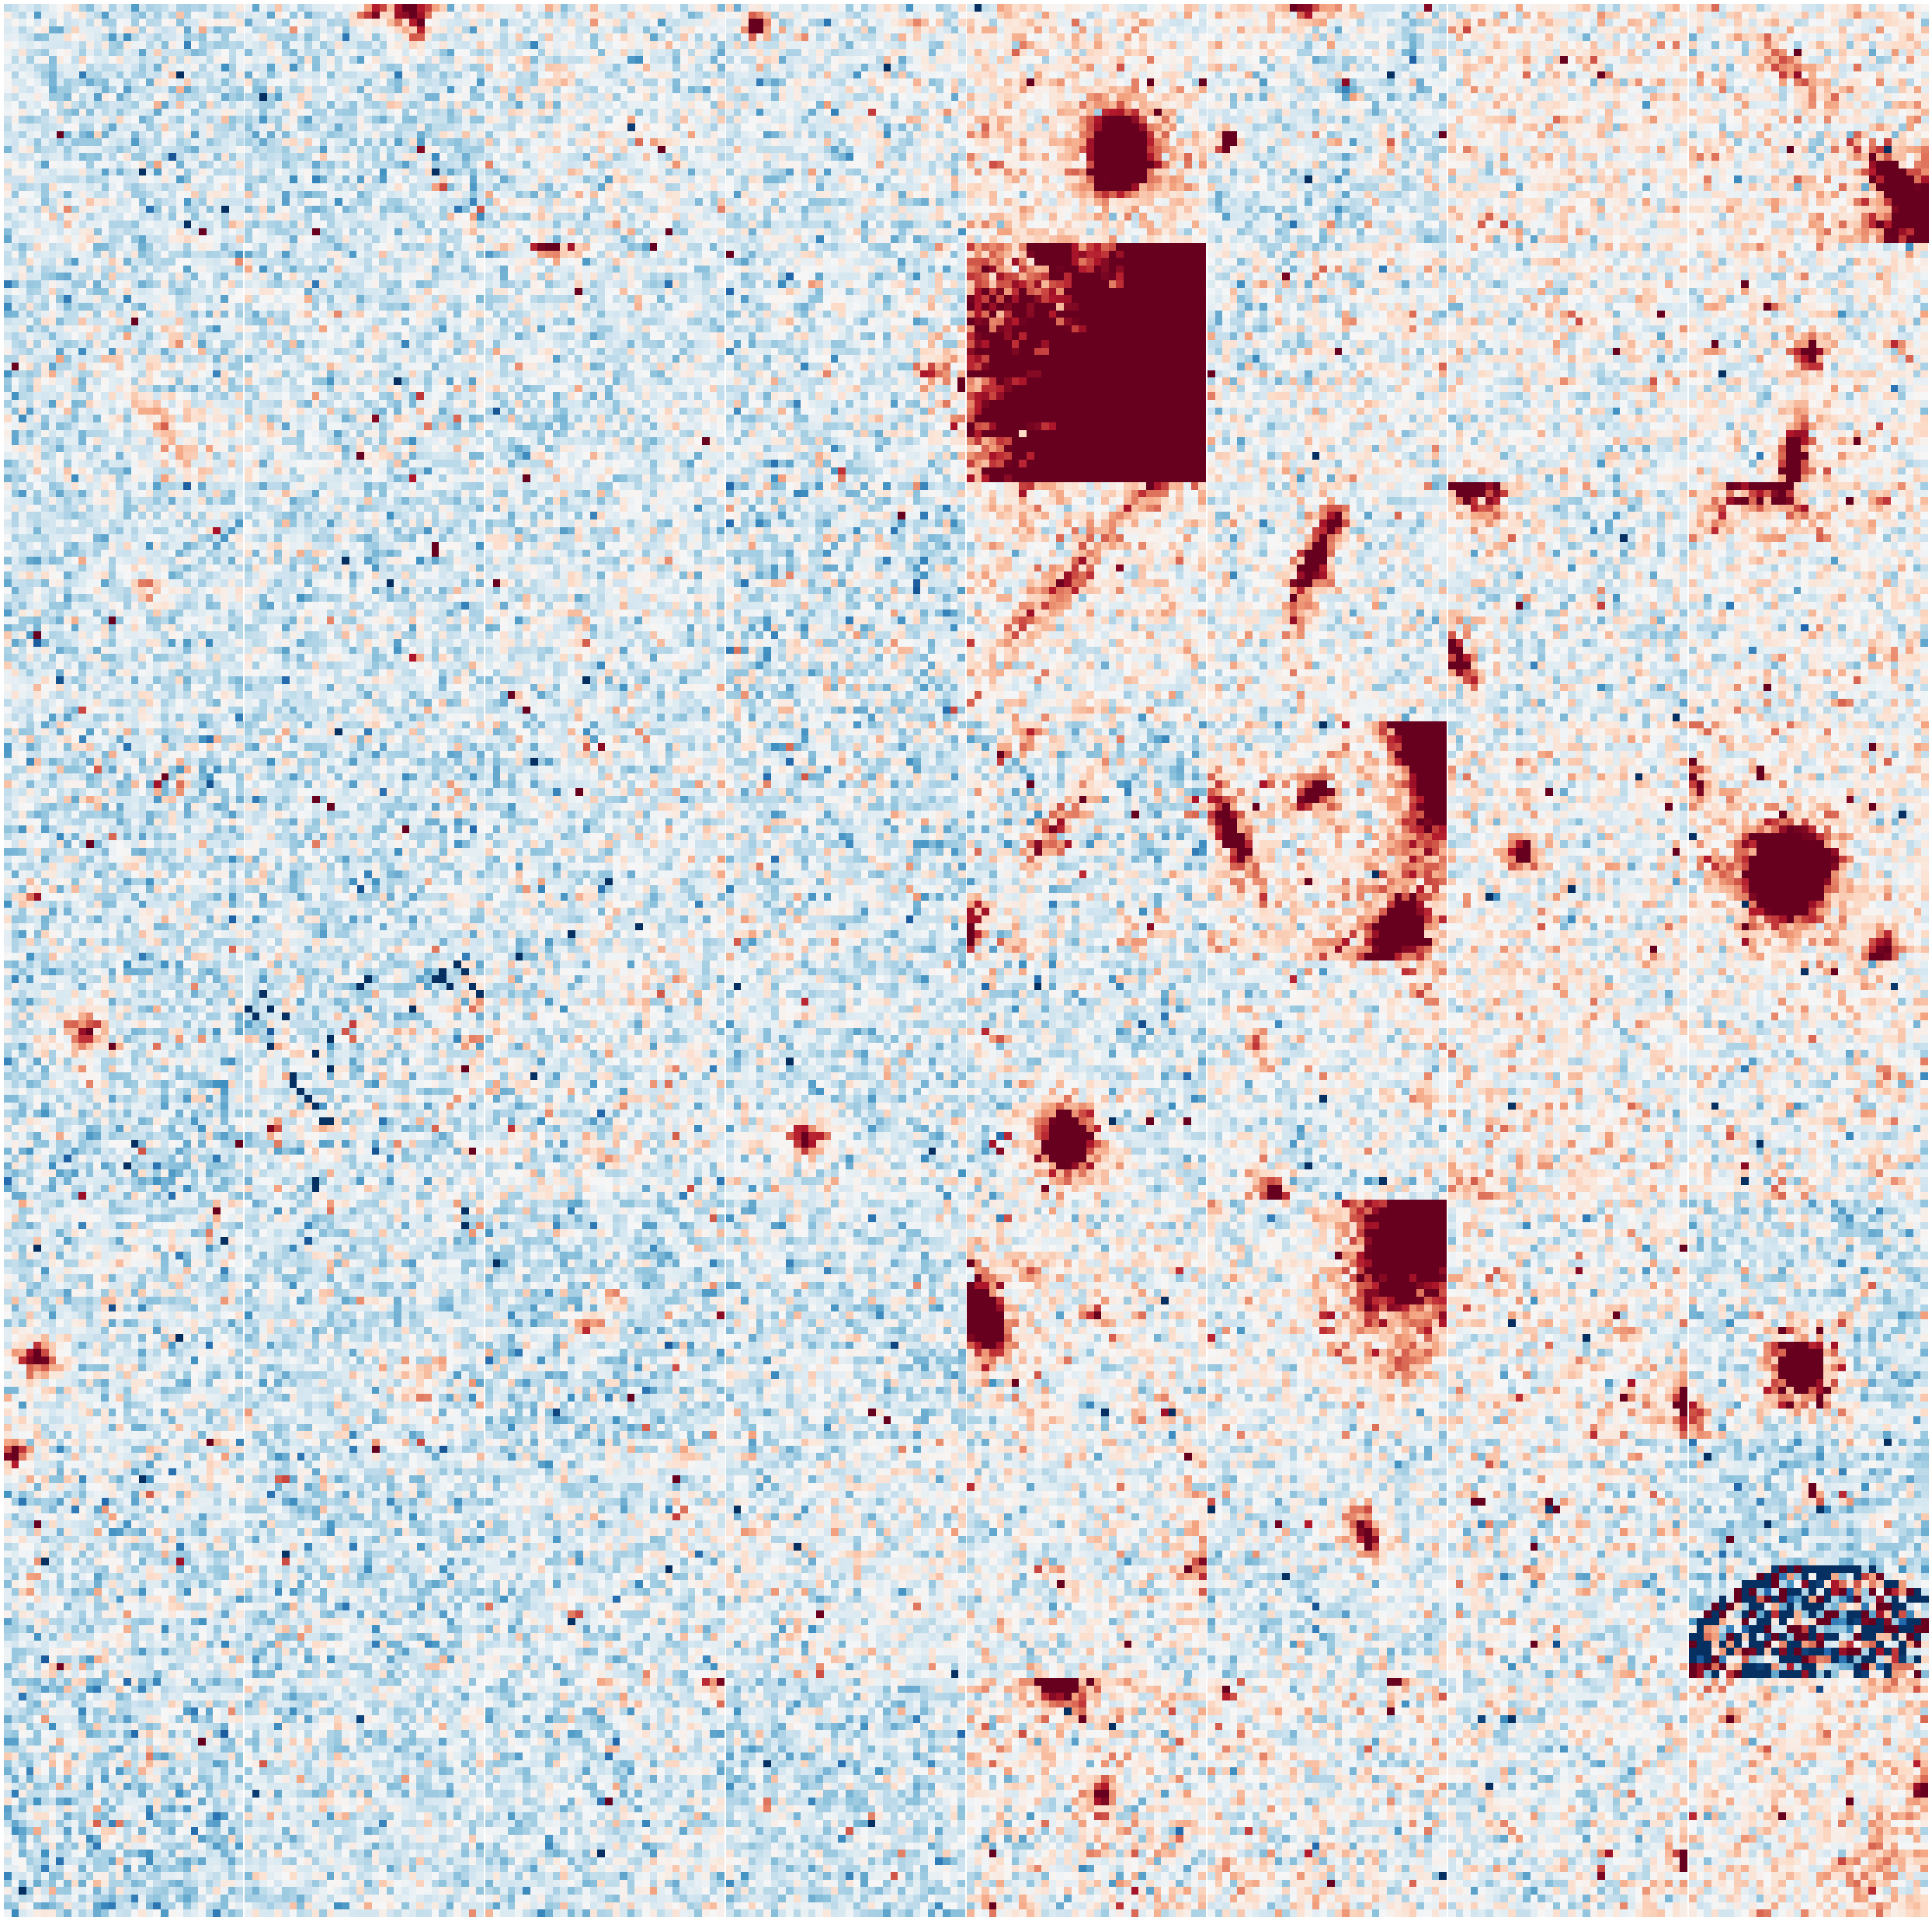

In [25]:
fig, axs = plt.subplots(8, 8, figsize=(32, 32))

F = "F160W"
for i in range(8):
    for j in range(4):
        k = np.random.randint(len(good_crops[F]))
        axs[i, j].imshow(good_crops[F][k], cmap="RdBu_r", vmin=-0.2, vmax=0.2)
        axs[i, j].axis("off")
        
    for j in range(4):
        k = np.random.randint(len(bad_crops[F]))
        axs[i, 4+j].imshow(bad_crops[F][k], cmap="RdBu_r", vmin=-0.2, vmax=0.2)
        axs[i, 4+j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

In [26]:
for key in good_crops.keys():
    np.save(f"../data/smacs_noise_dataset_{key}.npy", np.stack(good_crops[key]))

# Make JWST Science cutouts

In [215]:
data_dir = "../data/SMACSJ0723/JWST/"
cal_paths = glob.glob(data_dir + "*cal.fits")
i2d_paths = glob.glob(data_dir + "*i2d.fits")


filters = ["F115W", "F150W"]
# Cannot sort the calibration file this way since filter is not in the title
# cal_paths_sorted = {
#     "F150W": [p for p in cal_paths if "f150w" in p],
#     "F115W": [p for p in cal_paths if "f115w" in p],
# }
i2d_paths_sorted = {
    "F150W": [p for p in i2d_paths if "f150w" in p],
    "F115W": [p for p in i2d_paths if "f115w" in p],
}

In [231]:
i2d_paths_sorted

{'F150W': ['../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits'],
 'F115W': ['../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits']}

In [222]:
fits.open(i2d_paths_sorted["F150W"][0]).info()

Filename: ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     373   ()      
  1  SCI           1 ImageHDU        75   (10273, 4756)   float32   
  2  ERR           1 ImageHDU        10   (10273, 4756)   float32   
  3  CON           1 ImageHDU        10   (10273, 4756, 3)   int32   
  4  WHT           1 ImageHDU         9   (10273, 4756)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (10273, 4756)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (10273, 4756)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (10273, 4756)   float32   
  8  HDRTAB        1 BinTableHDU    824   72R x 407C   [23A, 5A, 3A, 45A, 7A, 13A, 5A, 6A, 7A, 10A, 4A, L, D, D, D, D, 32A, 50A, 33A, 21A, 3A, 3A, D, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 24A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 18A, 18A, 5A, D, D, D, D, D, D, D, D, D, D, 6A, 5A, 1A, 5A,

In [26]:
# fits.open(i2d_paths_sorted["F150W"][0])[0].header

In [251]:
targets = list(range(3))
coords = [coord1, coord2, coord3]#, coord4]
cutouts = {k: {i: [] for i in targets} for k in filters}
hdul = {k: [] for k in filters}
for target in targets:
    for f in filters:
        paths = i2d_paths_sorted[f]
        for i, path in enumerate(paths):
            print(f, path)
            hdul_obj, data, cutout = save_cutout(f"../data/smacs_jwst_i2d_target{target}_{f}.fits",
                                            pixels=64 if f=="F115W" else 128, # double resolution with F150W
                                            flc_or_flt_path=path,
                                            coordinate=coords[target],
                                            flux_smaller_than=5e-4 if f=="F115W" else 5e-5, # Used to compute statistics
                                            overwrite=True,
                                            # verbose=1,
                                            ver=1
                                            )
            cutouts[f][target].append(cutout)

F115W ../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits


Set DATE-AVG to '2022-06-17T09:06:06.285' from MJD-AVG.
Set DATE-END to '2022-06-17T10:01:37.405' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-07T04:05:22.536' from MJD-AVG.
Set DATE-END to '2022-06-07T05:14:03.242' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


F150W ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits
F115W ../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits
F150W ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits


Set DATE-AVG to '2022-06-17T09:06:06.285' from MJD-AVG.
Set DATE-END to '2022-06-17T10:01:37.405' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-07T04:05:22.536' from MJD-AVG.
Set DATE-END to '2022-06-07T05:14:03.242' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


F115W ../data/SMACSJ0723/JWST/jw02736-o003_t001_niriss_clear-f115w_i2d.fits
F150W ../data/SMACSJ0723/JWST/jw02736-o001_t001_nircam_clear-f150w_i2d.fits


Set DATE-AVG to '2022-06-17T09:06:06.285' from MJD-AVG.
Set DATE-END to '2022-06-17T10:01:37.405' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-07T04:05:22.536' from MJD-AVG.
Set DATE-END to '2022-06-07T05:14:03.242' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -32.910970 from OBSGEO-[XYZ].
Set OBSGEO-H to 1675594114.587 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [252]:
cutouts

{'F115W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f56d8dddb70>],
  1: [<astropy.nddata.utils.Cutout2D at 0x7f56d8b8da20>],
  2: [<astropy.nddata.utils.Cutout2D at 0x7f56d3ec3820>]},
 'F150W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f578e9fafb0>],
  1: [<astropy.nddata.utils.Cutout2D at 0x7f578b11c2e0>],
  2: [<astropy.nddata.utils.Cutout2D at 0x7f57905b10f0>]}}

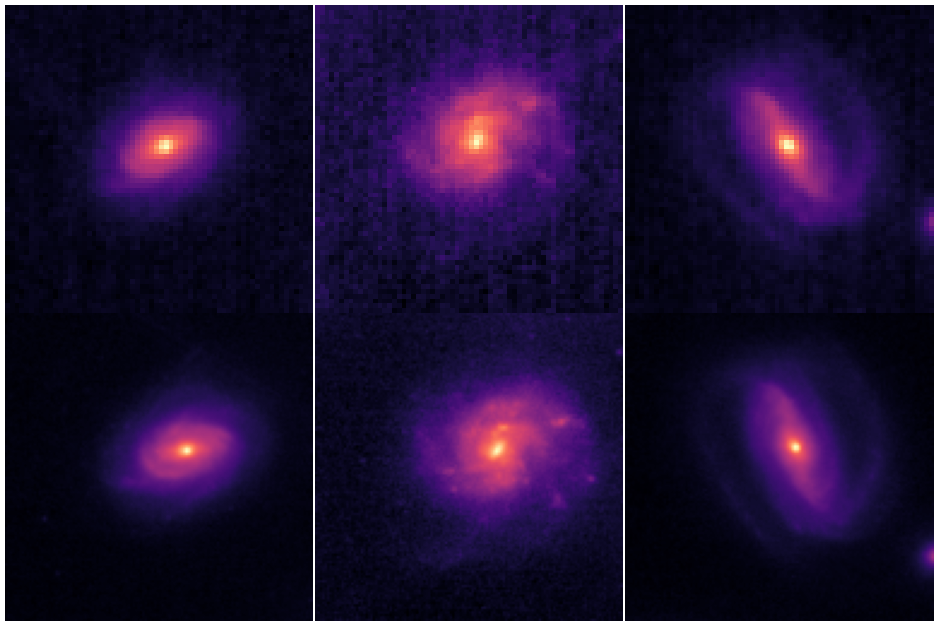

In [253]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

for i, f in enumerate(filters):
    for j in range(3):
        axs[i, j].imshow(cutouts[f][j][0].data, cmap="magma", norm=plt.cm.colors.LogNorm())
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

In [270]:
cutouts

{'F105W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f57905891b0>,
  1: [<astropy.nddata.utils.Cutout2D at 0x7f56d80a9a20>,
  2: [<astropy.nddata.utils.Cutout2D at 0x7f56d34cb430>,
   <astropy.nddata.utils.Cutout2D at 0x7f56d810ce20>]},
 'F125W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f56d80ab4f0>,
  1: [<astropy.nddata.utils.Cutout2D at 0x7f578e409090>,
  2: [<astropy.nddata.utils.Cutout2D at 0x7f578e7e75b0>,
   <astropy.nddata.utils.Cutout2D at 0x7f56d2ef2b60>]},
 'F160W': {0: [<astropy.nddata.utils.Cutout2D at 0x7f56d80aa620>,
  1: [<astropy.nddata.utils.Cutout2D at 0x7f56d34cbfa0>,
  2: [<astropy.nddata.utils.Cutout2D at 0x7f578e7e59c0>,
   <astropy.nddata.utils.Cutout2D at 0x7f56d3523310>]}}

In [275]:
(proj_plane_pixel_scales(cutouts["F105W"][0][0].wcs) * 3600 / 4).mean()

0.03204407112912643